## Prepare Data

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_util import *

In [2]:
import time

In [3]:
no_epochs=20
val_split=0.15
sequence_length = 16  # sequence length

#### Tranining Data set

In [4]:
train_df = read_data(get_files(r'.*Case[1-6]_CutFre20.xls'),cut_precent=0.1) # case 1 -6 for traning
train_df.head()

,distance,acceleration,displacement,force
0,195.166667,-0.971085,0.058862,171.311496
1,195.250000,-1.077395,0.058892,171.652377
2,195.333333,-1.167291,0.058921,171.871397
3,195.416667,-1.239130,0.058949,171.960719
4,195.500000,-1.291503,0.058976,171.913955


In [5]:
# Selecting the relevant features
train_features = train_df[['acceleration', 'displacement']]
train_target = train_df['force']

X_train, y_train = create_sequences(train_features, train_target, train_df['distance'],sequence_length)

#### Testing Data set

In [144]:
test_df = read_data(get_files(r'.*Case[7-8]_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Conv1D, Dense,LSTM,Bidirectional,Input,GRU,Flatten,Dropout,Attention
from tensorflow.keras import regularizers
from tensorflow import keras
from keras_self_attention import SeqSelfAttention

2024-05-05 02:09:42.480528: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
rnn_model = Sequential([
    SimpleRNN(32, input_shape=(sequence_length, 2), return_sequences=True),
    SimpleRNN(32, return_sequences=False),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

/Users/lahaale/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16, 32)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,233 (12.63 KB)

 Trainable params: 3,233 (12.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
rnn_history = rnn_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)


Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 20673.4590 - val_loss: 1534.6067
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 1870.6797 - val_loss: 457.4970
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 396.4947 - val_loss: 397.4595
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 342.1418 - val_loss: 446.8943
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 333.3252 - val_loss: 437.0309
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 325.1953 - val_loss: 426.2977
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 321.8519 - val_loss: 386.3055
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 316.0287 - val_loss: 376.5739
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 316.6309 - val_loss: 360.4401
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 311.5156 - val_loss: 408.3911
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 3

In [10]:
rnn_model.save("models/rnn_model.keras")
pd.DataFrame(data = rnn_history.history).to_csv("history/rnn_hist.csv")
time.sleep(60*5)

In [13]:
gru_model = Sequential([
    GRU(32, input_shape=(sequence_length, 2), return_sequences=True),
    GRU(32, return_sequences=False),
    # SeqSelfAttention(attention_activation='sigmoid'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 16, 32)         │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,825 (38.38 KB)

 Trainable params: 9,825 (38.38 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
gru_history = gru_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 57s 9ms/step - loss: 20095.1387 - val_loss: 1375.6228
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 1346.5798 - val_loss: 433.1844
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - loss: 342.9055 - val_loss: 357.8967
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - loss: 303.7186 - val_loss: 367.4003
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - loss: 297.0803 - val_loss: 374.2326
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - loss: 294.0302 - val_loss: 354.0826
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - loss: 290.1154 - val_loss: 347.4659
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - loss: 285.7038 - val_loss: 342.1783
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - loss: 279.9017 - val_loss: 339.8876
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - loss: 275.8648 - val_loss: 335.2879
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - loss: 2

In [15]:
gru_model.save("models/gru_model.keras")
pd.DataFrame(data = gru_history.history).to_csv("history/gru_hist.csv")
time.sleep(60*5)

In [16]:
# gru_att_model = Sequential([
#     GRU(32, input_shape=(sequence_length, 2), return_sequences=True),
#     SeqSelfAttention(attention_activation='sigmoid'),
#     GRU(32, return_sequences=False),
#     Dense(1)
# ])
# gru_att_model.compile(optimizer='adam', loss='mean_squared_error')
# gru_att_model.summary()
# gru_att_history = gru_att_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)

In [17]:
# gru_att_model.save("models/gru_att_model.keras")
# pd.DataFrame(data = gru_att_history.history).to_csv("history/gru_att_hist.csv")
# time.sleep(60*5)

In [18]:
def cnn_gru_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
    model = Sequential()
    model.add(Input(shape=(steps,feature_size)))
    model.add(Conv1D(64, 1, activation='relu'))
    model.add(GRU(32, return_sequences=True))
    model.add(GRU(32,return_sequences=False))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [19]:
cnn_gru_model = cnn_gru_model()
cnn_gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 16, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 16, 32)         │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,969 (62.38 KB)

 Trainable params: 15,969 (62.38 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
cnn_gru_history = cnn_gru_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - loss: 20372.5742 - val_loss: 1455.1710
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 1704.0165 - val_loss: 409.9655
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 375.5516 - val_loss: 364.0227
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 307.3993 - val_loss: 366.2887
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 296.9754 - val_loss: 342.2516
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 293.6230 - val_loss: 380.2704
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 289.2222 - val_loss: 331.3218
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 279.4073 - val_loss: 325.8766
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 257.4934 - val_loss: 217.1711
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 212.4889 - val_loss: 206.2678
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 1

In [21]:
cnn_gru_model.save("models/cnn_gru_model.keras")
pd.DataFrame(data = cnn_gru_history.history).to_csv("history/cnn_gru_hist.csv")
# time.sleep(60*5)

In [22]:
# reg = regularizers.l1_l2(0.01)
def lstm_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
    model = Sequential()
    # model.add(Input(shape=(steps,feature_size)))
    # model.add(Conv1D(64, 1, activation='relu'))
    model.add(LSTM(32,input_shape=(sequence_length, 2), return_sequences=True))
    model.add(LSTM(32,return_sequences=False))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [23]:
lstm_model = lstm_model()
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 32)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,833 (50.13 KB)

 Trainable params: 12,833 (50.13 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
lstm_history = lstm_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 20016.9707 - val_loss: 1404.4344
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 1288.7345 - val_loss: 381.9455
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 332.5386 - val_loss: 362.8103
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 300.5876 - val_loss: 392.7553
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: 295.4008 - val_loss: 366.4017
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 291.6630 - val_loss: 346.8707
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 286.5234 - val_loss: 343.8706
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 283.6902 - val_loss: 333.8952
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 282.3546 - val_loss: 341.3045
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 277.9584 - val_loss: 335.5133
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 2

In [25]:
lstm_model.save("models/lstm_model.keras")
pd.DataFrame(data = lstm_history.history).to_csv("history/lstm_hist.csv")
time.sleep(60*5)

In [26]:
# def dnn_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
#     model = Sequential()
#     model.add(Input(shape=(steps,feature_size)))
#     model.add(Flatten())
#     model.add(Dense(32))
#     model.add(Dense(32))
#     model.add(Dense(1))
#     model.compile(optimizer='adam', loss='mean_squared_error')
#     return model

# dnn_model = dnn_model()
# dnn_model.summary()

In [27]:
# dnn_history = dnn_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

In [28]:
# from sklearn.svm import SVR
# svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
# svr_rbf.fit(train_df[['acceleration','displacement']], train_df.force)

In [29]:
# x = X_train.reshape(X_train.shape[0],-1)

In [30]:

# gru_model.save("models/gru_model.keras")
# lstm_model.save("models/lstm_model.keras")
# gru_att_model.save("models/gru_att_model.keras")

In [31]:
# def dnn_model2(steps=sequence_length,feature_size=2, output_size=1,req=True):
#     model = Sequential()
#     model.add(Dense(32,input_dim=feature_size))
#     model.add(Dense(32))
#     model.add(Dense(1))
#     model.compile(optimizer='adam', loss='mean_squared_error')
#     return model

# dnn_model1 = dnn_model2()
# dnn_model1.summary()

In [32]:
# dnn_history1 = dnn_model1.fit(train_features, train_target,  epochs=no_epochs, validation_split=val_split, verbose=1)

In [33]:
# rnn_model.load_weights("models/rnn_model.keras")
# new_model = tf.keras.models.load_model('my_model.keras')

In [34]:
# rnn_model = tf.keras.models.load_model("models/rnn_model.keras")
# dnn_model = tf.keras.models.load_model("models/dnn_model.keras")
# lstm_model = tf.keras.models.load_model("models/lstm_model.keras")

In [115]:
rnn_pred = rnn_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
cnn_gru_pred = cnn_gru_model.predict(X_test)
# dnn_pred1 = dnn_model1.predict(test_features[sequence_length:])

2187/2187 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2187/2187 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
2187/2187 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2187/2187 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [36]:
lstm_pred.shape

(69983, 1)

In [37]:
gru_pred.shape

(69983, 1)

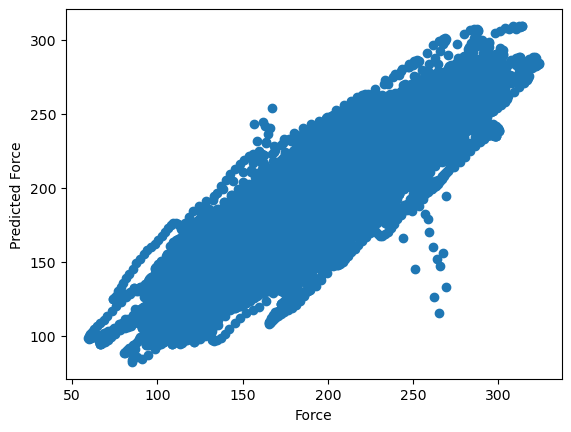

In [38]:
plt.scatter(y_test,lstm_pred);
plt.xlabel("Force")
plt.ylabel("Predicted Force");

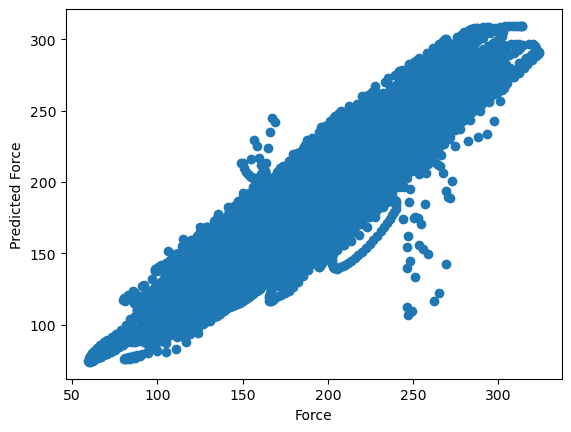

In [39]:
plt.scatter(y_test,cnn_gru_pred);
plt.xlabel("Force")
plt.ylabel("Predicted Force");

In [40]:
def plot_slot(start=500,end=601,filename="image"):
    epoch_count = range(start,end)

    plt.plot(epoch_count, y_test[start:end], 'ro-',linewidth=2.0,markevery=20)
    # plt.plot(epoch_count, dnn_pred1[start:end], 'm--',linewidth=2.0)
    # plt.plot(epoch_count, dnn_pred[start:end], 'b--',linewidth=2.0)
    plt.plot(epoch_count, gru_pred[start:end], 'm^--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, cnn_gru_pred[start:end], 'bX--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, rnn_pred[start:end], 'yh--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, lstm_pred[start:end], 'gd--',linewidth=2.0,markevery=20)
    plt.legend(['Force',"GRU","CNN-GRU", "RNN","LSTM"])
    plt.xlabel('Time Slots')
    plt.ylabel('Force')
    #plt.title(title)
    plt.grid(True)
    plt.savefig("images/"+filename+".pdf",dpi=200,format = "pdf")
    # plt.show()
    

In [41]:
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["figure.figsize"] = (8,6)
plt.style.use("classic")


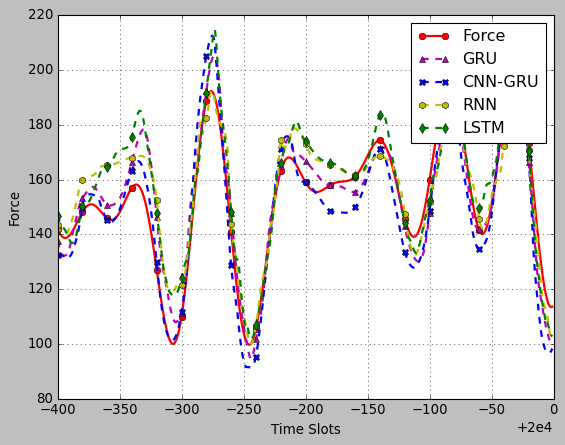

In [119]:
plot_slot(19600,20000,"ex2_train_Fre20_test_on_Fre20_Case7_8")

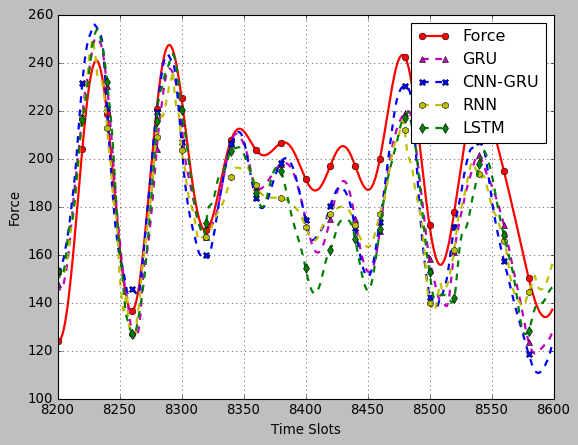

In [43]:
plot_slot(8200,8600,"ex11_Fre200_Case7_8")

In [44]:
df_val = pd.DataFrame(data = {
              # "DNN-TM":dnn_history.history["val_loss"],
              "RNN":rnn_history.history["val_loss"],
              "GRU":gru_history.history["loss"],
              "CNN_GRU":cnn_gru_history.history["loss"],
              "LSTM":rnn_history.history["val_loss"]
                                         })
df_val.head()
df_val.to_csv("history/val_loss.csv")

In [45]:
df_val = pd.DataFrame(data = {
              # "DNN-TM":dnn_history.history["loss"],
              "RNN":rnn_history.history["loss"],
              "GRU":gru_history.history["loss"],
              "CNN_GRU":cnn_gru_history.history["loss"],
              "LSTM":rnn_history.history["loss"]
                                         })
df_val.head()
df_val.to_csv("history/loss.csv")

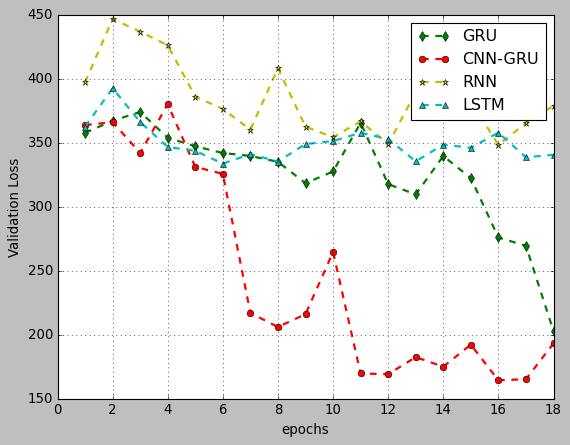

In [90]:
def plot_models_performance(gru=None, rnn=None, lstm=None,cnn_gru=None, title="Proctive Model"):
    lstm_accuracy = lstm.history['val_loss'][2:no_epochs]
    rnn_accuracy = rnn.history['val_loss'][2:no_epochs]
    gru_accuracy = gru.history['val_loss'][2:no_epochs]
    gru_att_acc = cnn_gru.history['val_loss'][2:no_epochs]


    # Create count of the number of epochs
    epoch_count = range(1, len(lstm_accuracy) + 1)

    # Visualize loss history
    plt.plot(epoch_count, gru_accuracy, 'gd--',linewidth=2.0)
    plt.plot(epoch_count, gru_att_acc, 'ro--',linewidth=2.0)
    plt.plot(epoch_count, rnn_accuracy, 'y*--',linewidth=2.0)
    plt.plot(epoch_count, lstm_accuracy, 'c^--',linewidth=2.0)
   
    plt.legend(['GRU','CNN-GRU', "RNN", "LSTM"])
    plt.xlabel('epochs')
    plt.ylabel('Validation Loss')
    plt.grid(True)
    plt.savefig("images/"+"val_loss.pdf",dpi=200,format = "pdf")

plot_models_performance(gru_history,rnn_history,lstm_history,cnn_gru_history,title="Adaptive Validation Loss")

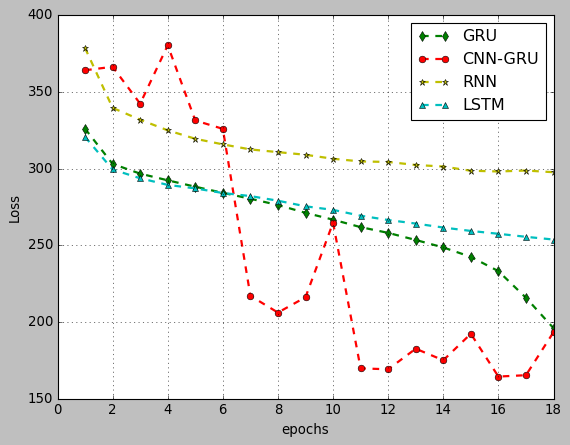

In [91]:
def plot_models_performance(gru=None, rnn=None, lstm=None, gru_att=None,title="Proctive Model"):
    lstm_accuracy = lstm.history['loss'][2:no_epochs]
    rnn_accuracy = rnn.history['loss'][2:no_epochs]
    gru_accuracy = gru.history['loss'][2:no_epochs]
    gru_att_acc = gru_att.history['val_loss'][2:no_epochs]


    # Create count of the number of epochs
    epoch_count = range(1, len(lstm_accuracy) + 1)

    # Visualize loss history
    plt.plot(epoch_count, gru_accuracy, 'gd--',linewidth=2.0)
    plt.plot(epoch_count, gru_att_acc, 'ro--',linewidth=2.0)
    plt.plot(epoch_count, rnn_accuracy, 'y*--',linewidth=2.0)
    plt.plot(epoch_count, lstm_accuracy, 'c^--',linewidth=2.0)
    # plt.plot(epoch_count, deep_nn_accuracy, 'b--')
    plt.legend(['GRU','CNN-GRU', "RNN", "LSTM"])
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    # plt.title(title)
    plt.grid(True)
    plt.savefig("images/"+"loss.pdf",dpi=200,format = "pdf")

plot_models_performance(gru_history,rnn_history,lstm_history,cnn_gru_history,title="Loss")

In [48]:
test_df = read_data(get_files(r'.*Case[7]_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)

In [87]:
from sklearn.metrics import mean_squared_error
# from tensorflow.keras.metrics import MeanSquaredError 

In [173]:
def plot_error(finame="bar"):
    rnn_pred = rnn_model.predict(X_test).reshape(-1)
    gru_pred = gru_model.predict(X_test).reshape(-1)
    lstm_pred = lstm_model.predict(X_test).reshape(-1)
    gru_att_pred = cnn_gru_model.predict(X_test).reshape(-1)
    # dnn_pred1 = dnn_model1.predict(test_features[sequence_length:])

    rnn_mse = mean_squared_error(y_test,rnn_pred)
    # dnn_tm_mse = mean_squared_error(dnn_pred, y_test)
    # dnn_mse = mean_squared_error(dnn_pred1, y_test)
    gru_mse = mean_squared_error(y_test,gru_pred)
    gru_att_mse = mean_squared_error(y_test,gru_att_pred)
    lstm_mse = mean_squared_error(y_test,lstm_pred)

    fig, ax = plt.subplots()
    fruits = ['RNN','GRU','CNN-GRU', 'LSTM']
    counts = [rnn_mse, gru_mse, gru_att_mse, lstm_mse]
    bar_labels = ['RNN','GRU','CNN-GRU', 'LSTM']
    bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

    ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

    ax.set_ylabel('Mean Sqaure Error',fontsize=17) 
    # ax.set_title('Fruit supply by kind and color')
    # ax.legend(title='Models')
    plt.grid(True)

    plt.xticks(rotation=45,fontsize=17) 
    plt.yticks(fontsize=17) 
    # plt.show()
    plt.savefig("images/"+finame+".pdf",dpi=200,format = "pdf")
    return counts

2187/2187 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2187/2187 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2187/2187 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2187/2187 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


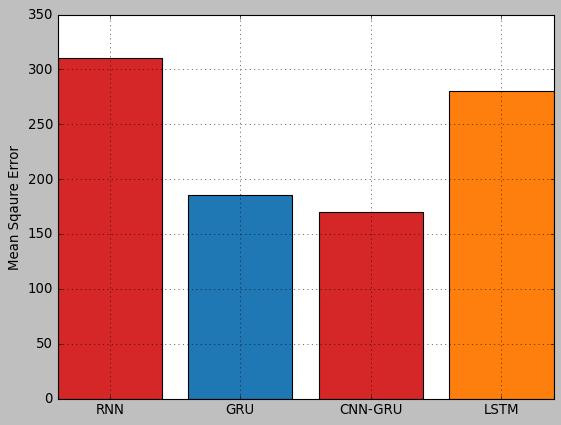

In [149]:
trained_Fre20_test_Fre200_case7_8 = plot_error("trained_Fre20_test_Fre200_case7_8")

In [120]:
test_df = read_data(get_files(r'.*Case[2-3]_CutFre200.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)

2303/2303 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


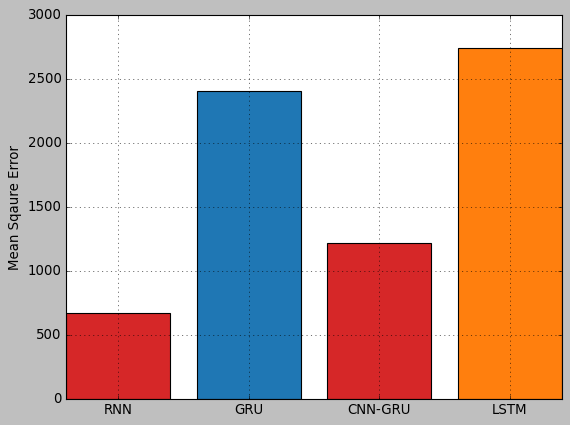

In [53]:
plot_error("trained_Fre20_test_on_Fre200_case2_3")

In [121]:
rnn_pred = rnn_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
cnn_gru_pred = cnn_gru_model.predict(X_test)

2303/2303 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


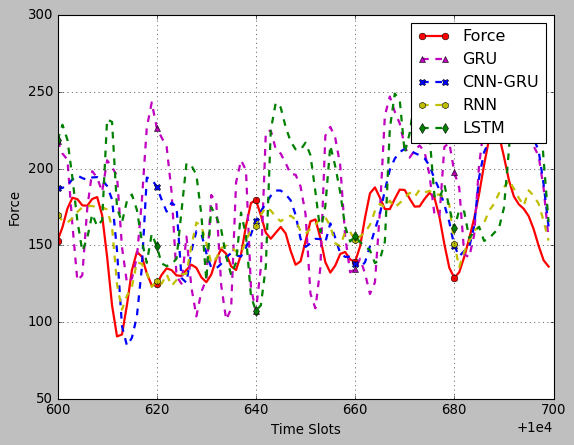

In [126]:
plot_slot(10600,10700,"ex23_trained_Fre20_test_on_Fre200_case2_3")

In [127]:
test_df = read_data(get_files(r'.*Case[3-4]_CutFre50.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)

2533/2533 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


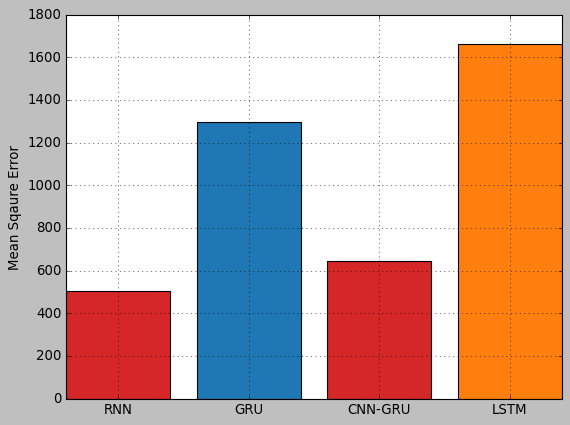

In [57]:
plot_error("trained_Fre20_test_on_Fre50_case3_4")

In [129]:
rnn_pred = rnn_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
cnn_gru_pred = cnn_gru_model.predict(X_test)

2533/2533 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


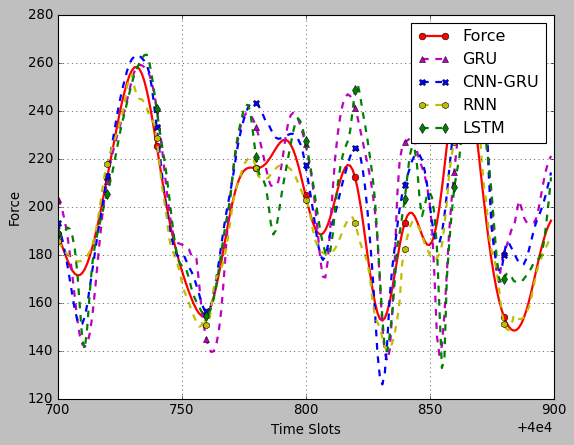

In [134]:
plot_slot(40700,40900,"ex25_trained_Fre20_test_on_Fre50_case3_4")

In [135]:
test_df = read_data(get_files(r'.*Case[4-5]_CutFre100.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)

2533/2533 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


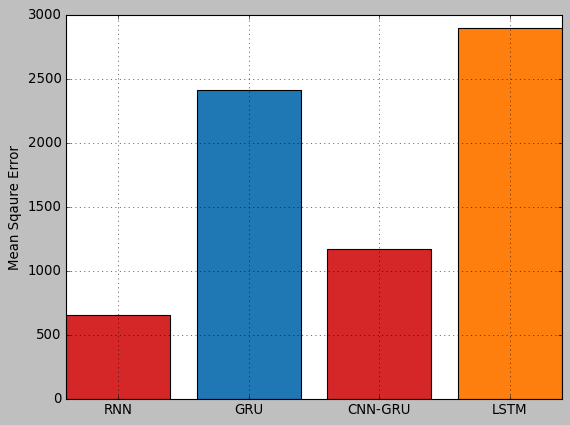

In [61]:
plot_error("trained_Fre20_test_on_Fre100_case4_5")

In [136]:
rnn_pred = rnn_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
cnn_gru_pred = cnn_gru_model.predict(X_test)

2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


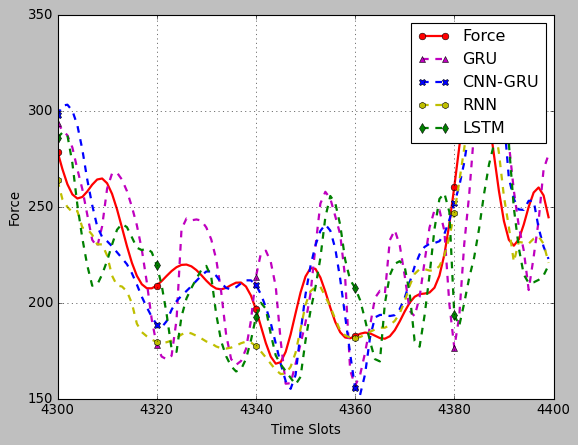

In [137]:
plot_slot(4300,4400,"ex27_trained_Fre20_test_on_Fre100_case4_5")

2418/2418 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


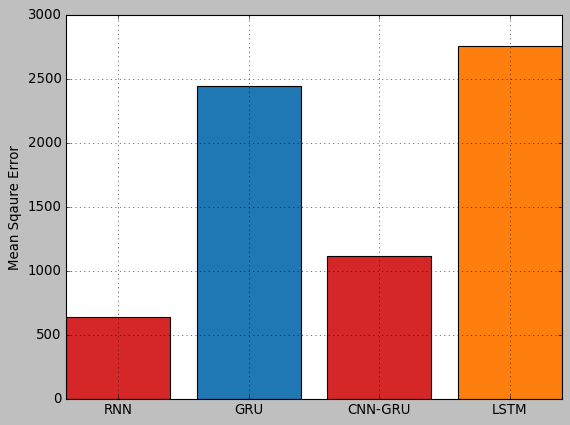

In [138]:
test_df = read_data(get_files(r'.*Case[5-6]_CutFre150.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)
plot_error("trained_Fre20_test_on_Fre150_case5_6")

In [139]:
rnn_pred = rnn_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
cnn_gru_pred = cnn_gru_model.predict(X_test)

2418/2418 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


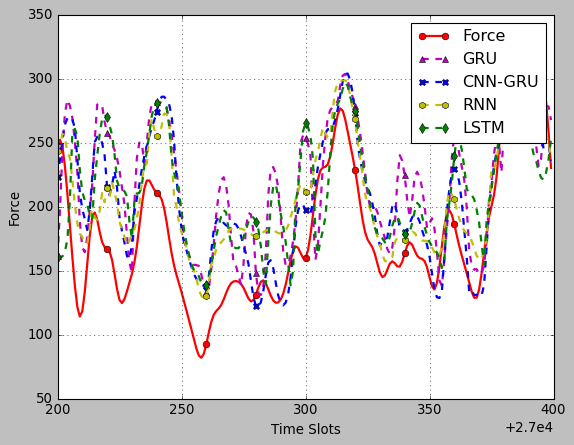

In [143]:
plot_slot(27200,27400,"ex31_trained_Fre20_test_on_Fre150_case5_6")

2533/2533 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


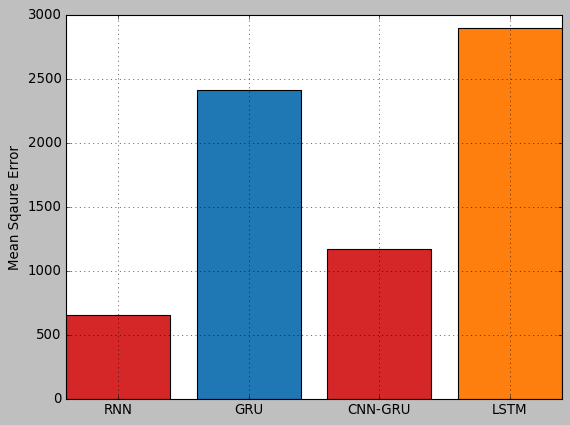

In [157]:
test_df = read_data(get_files(r'.*Case[4-5]_CutFre100.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)
trained_Fre200_test_on_Fre100_case4_5 = plot_error("trained_Fre200_test_on_Fre100_case4_5")

In [167]:
error_df = pd.DataFrame(data={
    "F 20\n C 7,8":trained_Fre20_test_Fre200_case7_8,
    "F 50\n C 5,6":trained_Fre20_test_on_Fre50_case5_6,
    "F 100 \n C 4,5":trained_Fre20_test_on_Fre100_case4_5,
    "F 150\n C 3,4":trained_Fre20_test_on_Fre150_case3_4,
    "F 200\n C 1,2":trained_Fre20_test_on_Fre200_case1_2
                             })
error_df.index = ['RNN','GRU','CNN-GRU', 'LSTM']
error_df.head()

,"F 20\n C 7,8","F 50\n C 5,6","F 100 \n C 4,5","F 150\n C 3,4","F 200\n C 1,2"
RNN,310.479823,480.838003,649.599767,672.049661,555.310184
GRU,185.339548,1191.981108,2411.542568,2427.290787,2315.752171
CNN-GRU,170.356856,569.992852,1172.139734,1226.539102,1114.291003
LSTM,280.442432,1468.905834,2893.519561,2819.133322,2592.965606


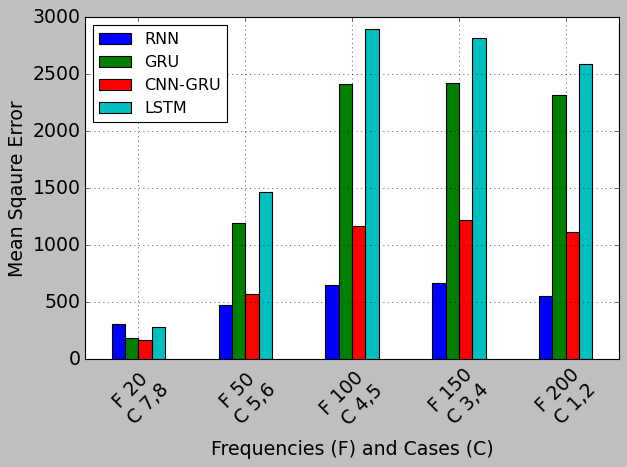

In [176]:
plt.rcParams.update({'figure.autolayout': True})
error_df.transpose().plot(kind="bar")
plt.xlabel("Frequencies (F) and Cases (C)",fontsize=17) 
plt.ylabel("Mean Sqaure Error",fontsize=17) 
plt.xticks(rotation=45,fontsize=17) 
plt.yticks(fontsize=17) 
plt.grid(True)
plt.savefig("images/mode_freq20.pdf",dpi=200,format = "pdf")

NameError: name 'read_data' is not defined